# 🧠 Deep Learning Practical Assignment (Adult Income Dataset)

## 📌 Dataset
We will use the **Adult Income dataset** (also known as the Census Income dataset).  
The task is to predict whether a person earns **more than $50K/year** based on demographic and employment attributes.

---


In [1]:
# Option 1: Using OpenML via scikit-learn
from sklearn.datasets import fetch_openml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset from OpenML
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame

print(df.head())
print(df.shape)  # (48842, 15)


   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  class  
0       

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [3]:
for col in ["workclass", "occupation", "native-country"]:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_914/3603648498.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [4]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Private,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K


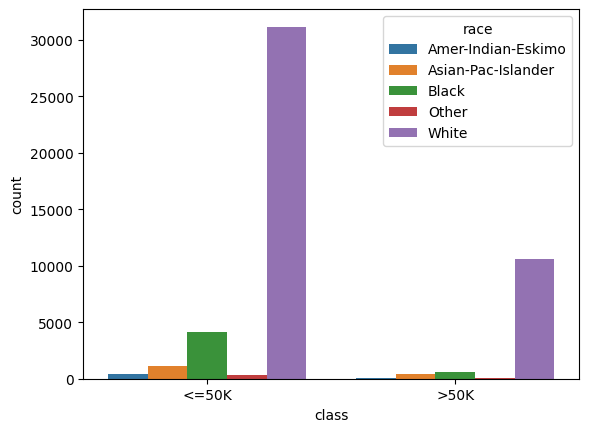

In [5]:
sns.countplot(x = 'class', hue = 'race', data = df)
plt.show()

## Part 0: Data Preparation
1. Load the dataset into a DataFrame.
2. Split the data into **training, validation, and test sets**.  
   - Suggested: 70% training, 15% validation, 15% test.
3. Apply any necessary preprocessing:
   - Handle categorical features (encoding).
   - Scale numerical features if needed.
4. After training your models, always report results on:
   - **Training accuracy**
   - **Validation accuracy**
   - **Test accuracy**
5. At the end of the assignment, **compare all methods** across train, validation, and test sets.


In [6]:
X = df.drop(columns="class")
y = df["class"]

In [7]:
y.value_counts()

,count
class,
<=50K,37155
>50K,11687


In [8]:
y = y.map({"<=50K":0, ">50K":1})

In [9]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [10]:
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [13]:
train_cols = X_train.columns
X_val = X_val.reindex(columns=train_cols, fill_value=0)
X_test = X_test.reindex(columns=train_cols, fill_value=0)


## Part 1: Optimizers
1. Train the same neural network using:
   - Stochastic Gradient Descent (SGD)
   - SGD with Momentum
   - Adam
2. Compare the training and validation accuracy for each optimizer.
3. Which optimizer converges the fastest? Which gives the best generalization?
4. Explain *why* Adam often performs better than plain SGD.

---


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def create_model(optimizer):

    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [16]:
from tensorflow.keras.optimizers import SGD, Adam
import time

optimizers = {
    "SGD": SGD(),
    "SGD_Momentum": SGD(momentum=0.9),
    "Adam": Adam()
}

optimizer_results = []

# Convert DataFrames to float32 NumPy arrays for Keras compatibility
X_train_for_keras = X_train.astype('float32').values
X_val_for_keras = X_val.astype('float32').values
X_test_for_keras = X_test.astype('float32').values

# Convert target Series to int32 NumPy arrays for Keras compatibility
y_train_for_keras = y_train.astype('int32').values
y_val_for_keras = y_val.astype('int32').values
y_test_for_keras = y_test.astype('int32').values

for name, opt in optimizers.items():

    model = create_model(opt)
    start_time = time.time()

    history = model.fit(
        X_train_for_keras, y_train_for_keras,
        validation_data=(X_val_for_keras, y_val_for_keras),
        epochs=20,
        batch_size=32,
        verbose=0
    )
    end_time = time.time()

    train_acc = model.evaluate(X_train_for_keras, y_train_for_keras, verbose=0)[1]
    val_acc = model.evaluate(X_val_for_keras, y_val_for_keras, verbose=0)[1]
    test_acc = model.evaluate(X_test_for_keras, y_test_for_keras, verbose=0)[1]

    optimizer_results.append({
        "Optimizer": name,
        "Training Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Test Accuracy": test_acc,
        "Training Time": end_time - start_time,
        "Best Val Accuracy": max(history.history["val_accuracy"])
    })

optimizer_results = pd.DataFrame(optimizer_results)

print(optimizer_results)


      Optimizer  Training Accuracy  Validation Accuracy  Test Accuracy  \
0           SGD           0.856825             0.858449       0.866931   
1  SGD_Momentum           0.865454             0.862817       0.860516   
2          Adam           0.876832             0.854764       0.855193   

   Training Time  Best Val Accuracy  
0     111.253994           0.861589  
1      72.955153           0.864728  
2      79.431547           0.863090  


**Fastest convergence:** SGD with momentum\
**Best Generalization:** SGD with momentum\
Adam performs better than SDG because it uses momentum and adaptive learning rate so it adjusts learning rates automatically, making training more stable than SGD


## Part 2: Batch Size
1. Train the same model with different batch sizes (e.g., 1, 32, 128, 1024).
2. Compare:
   - Training speed
   - Validation accuracy
   - Test accuracy
   - Generalization ability
3. Which batch size leads to the **noisiest gradient updates**?
4. Which batch size generalizes better and why?

In [24]:
batch_sizes = [1, 32, 128, 1024]

batch_results = []

for batch in batch_sizes:

    model = create_model(Adam())
    start_time = time.time()

    history = model.fit(
        X_train_for_keras, y_train_for_keras,
        validation_data=(X_val_for_keras, y_val_for_keras),
        epochs=20,
        batch_size=batch,
        verbose=0
    )
    end_time = time.time()

    train_acc = model.evaluate(X_train_for_keras, y_train_for_keras, verbose=0)[1]
    val_acc = model.evaluate(X_val_for_keras, y_val_for_keras, verbose=0)[1]
    test_acc = model.evaluate(X_test_for_keras, y_test_for_keras, verbose=0)[1]

    batch_results.append({
        "Batch Size": batch,
        "Training Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Test Accuracy": test_acc,
        "Training Time (s)": end_time - start_time
    })

batch_results = pd.DataFrame(batch_results)

print(batch_results)

   Batch Size  Training Accuracy  Validation Accuracy  Test Accuracy  \
0           1           0.871157             0.860906       0.864064   
1          32           0.879201             0.857221       0.857923   
2         128           0.873088             0.859405       0.861744   
3        1024           0.863085             0.859951       0.864610   

   Training Time (s)  
0        2556.678043  
1          80.414531  
2          26.458729  
3          11.585159  


**Noisest gradients:** batch size=1\
**Best generalization:** 32 or 128


## Part 3: Overfitting and Regularization
1. Train a large neural network (many parameters) on the dataset.
2. Observe training vs. validation accuracy.  
   - Do you see signs of overfitting?
3. Apply regularization techniques:
   - **L2 regularization**
   - **Dropout**
4. Compare the validation results before and after regularization.
5. Which regularization method was more effective in reducing overfitting? Why?

---


In [19]:
from tensorflow.keras.layers import Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Convert y_train and y_val to numerical numpy arrays
y_train_for_keras = y_train.astype('int32').values
y_val_for_keras = y_val.astype('int32').values

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation="relu"),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_for_keras, y_train_for_keras,
    validation_data=(X_val_for_keras, y_val_for_keras),
    epochs=30,
    batch_size=32,
    verbose=0
)

regularization_results = []

regularization_results.append({
    "Method": "No Regularization",
    "Train Accuracy": history.history["accuracy"][-1],
    "Val Accuracy": history.history["val_accuracy"][-1]
})


In [22]:
#L2 Regularization
from tensorflow.keras.layers import Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Convert y_train and y_val to numerical numpy arrays
y_train_for_keras = y_train.astype('int32').values
y_val_for_keras = y_val.astype('int32').values

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation="relu", kernel_regularizer=l2(0.001)),
    Dense(256, activation="relu", kernel_regularizer=l2(0.001)),
    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_for_keras, y_train_for_keras,
    validation_data=(X_val_for_keras, y_val_for_keras),
    epochs=30,
    batch_size=32,
    verbose=0
)

regularization_results.append({
    "Method": "L2 Regularization",
    "Train Accuracy": history.history["accuracy"][-1],
    "Val Accuracy": history.history["val_accuracy"][-1]
})

In [23]:
#Dropout
from tensorflow.keras.layers import Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Convert y_train and y_val to numerical numpy arrays
y_train_for_keras = y_train.astype('int32').values
y_val_for_keras = y_val.astype('int32').values

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_for_keras, y_train_for_keras,
    validation_data=(X_val_for_keras, y_val_for_keras),
    epochs=30,
    batch_size=32,
    verbose=0
)

regularization_results.append({
    "Method": "Dropout",
    "Train Accuracy": history.history["accuracy"][-1],
    "Val Accuracy": history.history["val_accuracy"][-1]
})

print(pd.DataFrame(regularization_results))

              Method  Train Accuracy  Val Accuracy
0  No Regularization        0.919623      0.836473
1  L2 Regularization        0.858492      0.863227
2            Dropout        0.869870      0.863909


L2 Regularization and dropout are effective in reducing overfitting because they produce the smallest gap between train and val accuracy

## Part 4: Early Stopping
1. Train the model for many epochs without early stopping.  
   - Plot training, validation, and test curves.
2. Train again with **early stopping** (monitor validation loss).
3. Compare the number of epochs trained and the final validation/test accuracy.
4. Explain how early stopping helps prevent overfitting.

---

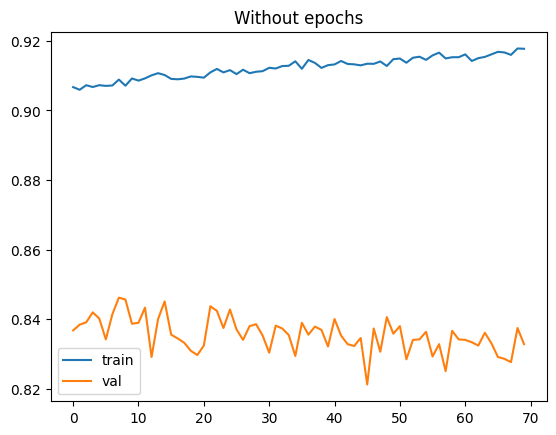

In [28]:
history = model.fit(
    X_train_for_keras, y_train_for_keras,
    validation_data=(X_val_for_keras, y_val_for_keras),
    epochs=70,
    batch_size=32,
    verbose=0
)
without_es = len(history.history["loss"])
val_acc_no = model.evaluate(X_val_for_keras, y_val_for_keras, verbose=0)[1]
test_acc_no = model.evaluate(X_test_for_keras, y_test_for_keras, verbose=0)[1]

import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Without epochs")
plt.legend()
plt.show()


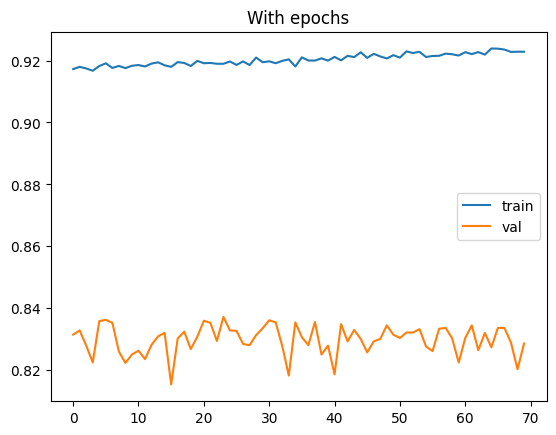

In [29]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_for_keras, y_train_for_keras,
    validation_data=(X_val_for_keras, y_val_for_keras),
    epochs=70,
    batch_size=32,
    verbose=0
)

with_es = len(history.history["loss"])
val_acc_es = model.evaluate(X_val_for_keras, y_val_for_keras, verbose=0)[1]
test_acc_es = model.evaluate(X_test_for_keras, y_test_for_keras, verbose=0)[1]

import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("With epochs")
plt.legend()
plt.show()

In [31]:
early_results = pd.DataFrame({
    "Model": ["Without Early Stopping", "With Early Stopping"],
    "Epochs Trained": [without_es, with_es],
    "Validation Accuracy": [val_acc_no, val_acc_es],
    "Test Accuracy": [test_acc_no, test_acc_es]
})

print(early_results)

                    Model  Epochs Trained  Validation Accuracy  Test Accuracy
0  Without Early Stopping              70             0.832787       0.829671
1     With Early Stopping              70             0.828556       0.827760


Early stopping reduces overfitting and saves training time

## Part 5: Reflection
1. Summarize what you learned about:
   - The role of optimizers
   - The effect of batch size
   - Regularization methods
   - Early stopping
   - Train/validation/test splits
2. If you had to train a deep learning model on a new tabular dataset, what choices would you make for:
   - Optimizer
   - Batch size
   - Regularization
   - Early stopping
   - Data splitting strategy  
   and why?

**Role of Optimizers** control how model weights are updated during training.

**Effect of Batch Size**: Small batch sizes introduce noisy gradient updates, Large batch sizes are faster but may lead to worse generalization.

**Regularization Methods**: L2 regularization penalizes large weights, while Dropout randomly disables neurons to encourage robust feature learning.

**Early Stopping**: monitors validation performance and stops training when the model stops improving, which prevents overfitting and reduces training time.

**Train / Validation / Test Splits**\
Training set: used to train the model
Validation set: used to tune hyperparameters
Test set: used for final evaluation of the model

#For new dataset:
**optimizer:** SGD With momentum\
**Batch size:** 32 \
**Regularization:** L2 regularization \
**Early stopping:** use early stopping \
**Data splitting:** 70% training, 15% validation, 15% test